# Lung Segmentation

In [1]:
import torch

print('PyTorch version:', torch.__version__)
print('CUDA available:', torch.cuda.is_available())
print('Device:', 'cuda' if torch.cuda.is_available() else 'cpu')

PyTorch version: 2.10.0+cu126
CUDA available: True
Device: cuda


### Preprocess JSRT + SHCXR Dataset

In [2]:
from preprocess import preprocess_all
preprocess_all()

Preprocessing dataset : JSRT
Total raw images found : 247
Total raw masks found : 247
Matched image-mask pairs : 247
Images without masks ignored: 0
Masks without images ignored: 0
Saved preprocessed image to data\jsrt\images
Saved preprocessed mask to data\jsrt\masks
JSRT preprocessing complete
Preprocessing dataset : SHCXR
Total raw images found : 662
Total raw masks found : 566
Matched image-mask pairs : 566
Images without masks ignored: 96
Masks without images ignored: 0
Saved preprocessed image to data\shcxr\images
Saved preprocessed mask to data\shcxr\masks
SHCXR preprocessing complete


### Training

#### UNet on SHCXR

In [3]:
!python train.py --model unet --dataset shcxr --image_dir data/shcxr/images --mask_dir data/shcxr/masks --epochs 25 --batch_size 8 --lr 0.0001

Using device: cuda
Training unet on shcxr
Epoch [1/25] - Loss: 0.6968 - Val Dice: 0.9531 - Val IoU: 0.9115
Epoch [2/25] - Loss: 0.5139 - Val Dice: 0.9543 - Val IoU: 0.9136
Epoch [3/25] - Loss: 0.4528 - Val Dice: 0.9545 - Val IoU: 0.9141
Epoch [4/25] - Loss: 0.4134 - Val Dice: 0.9584 - Val IoU: 0.9212
Epoch [5/25] - Loss: 0.3752 - Val Dice: 0.9589 - Val IoU: 0.9221
Epoch [6/25] - Loss: 0.3429 - Val Dice: 0.9563 - Val IoU: 0.9174
Epoch [7/25] - Loss: 0.3145 - Val Dice: 0.9582 - Val IoU: 0.9210
Epoch [8/25] - Loss: 0.2907 - Val Dice: 0.9587 - Val IoU: 0.9218
Epoch [9/25] - Loss: 0.2678 - Val Dice: 0.9601 - Val IoU: 0.9246
Epoch [10/25] - Loss: 0.2512 - Val Dice: 0.9587 - Val IoU: 0.9221
Epoch [11/25] - Loss: 0.2345 - Val Dice: 0.9590 - Val IoU: 0.9225
Epoch [12/25] - Loss: 0.2197 - Val Dice: 0.9396 - Val IoU: 0.8936
Epoch [13/25] - Loss: 0.2160 - Val Dice: 0.9591 - Val IoU: 0.9228
Epoch [14/25] - Loss: 0.1987 - Val Dice: 0.9603 - Val IoU: 0.9250
Epoch [15/25] - Loss: 0.1854 - Val Dice: 0.

d:\0. Omisha\UoU\Sem 4\DLI\Lung-Segmentation\train.py:66: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=use_amp)
d:\0. Omisha\UoU\Sem 4\DLI\Lung-Segmentation\train.py:81: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=use_amp):


#### UNet on JSRT

In [4]:
!python train.py --model unet --dataset jsrt --image_dir data/jsrt/images --mask_dir data/jsrt/masks --epochs 25 --batch_size 8 --lr 0.0001

Using device: cuda
Training unet on jsrt
Epoch [1/25] - Loss: 0.7647 - Val Dice: 0.8448 - Val IoU: 0.7346
Epoch [2/25] - Loss: 0.4458 - Val Dice: 0.9639 - Val IoU: 0.9307
Epoch [3/25] - Loss: 0.3959 - Val Dice: 0.9721 - Val IoU: 0.9459
Epoch [4/25] - Loss: 0.3643 - Val Dice: 0.9714 - Val IoU: 0.9447
Epoch [5/25] - Loss: 0.3396 - Val Dice: 0.9746 - Val IoU: 0.9506
Epoch [6/25] - Loss: 0.3192 - Val Dice: 0.9761 - Val IoU: 0.9535
Epoch [7/25] - Loss: 0.2995 - Val Dice: 0.9769 - Val IoU: 0.9551
Epoch [8/25] - Loss: 0.2797 - Val Dice: 0.9765 - Val IoU: 0.9542
Epoch [9/25] - Loss: 0.2625 - Val Dice: 0.9748 - Val IoU: 0.9512
Epoch [10/25] - Loss: 0.2489 - Val Dice: 0.9769 - Val IoU: 0.9549
Epoch [11/25] - Loss: 0.2347 - Val Dice: 0.9778 - Val IoU: 0.9568
Epoch [12/25] - Loss: 0.2223 - Val Dice: 0.9781 - Val IoU: 0.9572
Epoch [13/25] - Loss: 0.2110 - Val Dice: 0.9780 - Val IoU: 0.9572
Epoch [14/25] - Loss: 0.2001 - Val Dice: 0.9780 - Val IoU: 0.9570
Epoch [15/25] - Loss: 0.1893 - Val Dice: 0.9

d:\0. Omisha\UoU\Sem 4\DLI\Lung-Segmentation\train.py:66: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=use_amp)
d:\0. Omisha\UoU\Sem 4\DLI\Lung-Segmentation\train.py:81: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=use_amp):


#### ResUNet on SHCXR

In [5]:
!python train.py --model resunet --dataset shcxr --image_dir data/shcxr/images --mask_dir data/shcxr/masks --epochs 25 --batch_size 8 --lr 0.0001

Using device: cuda
Training resunet on shcxr
Epoch [1/25] - Loss: 0.4923 - Val Dice: 0.9393 - Val IoU: 0.8866
Epoch [2/25] - Loss: 0.2531 - Val Dice: 0.9563 - Val IoU: 0.9174
Epoch [3/25] - Loss: 0.2101 - Val Dice: 0.9578 - Val IoU: 0.9202
Epoch [4/25] - Loss: 0.1830 - Val Dice: 0.9583 - Val IoU: 0.9211
Epoch [5/25] - Loss: 0.1663 - Val Dice: 0.9587 - Val IoU: 0.9220
Epoch [6/25] - Loss: 0.1543 - Val Dice: 0.9580 - Val IoU: 0.9208
Epoch [7/25] - Loss: 0.1410 - Val Dice: 0.9581 - Val IoU: 0.9210
Epoch [8/25] - Loss: 0.1309 - Val Dice: 0.9582 - Val IoU: 0.9212
Epoch [9/25] - Loss: 0.1238 - Val Dice: 0.9593 - Val IoU: 0.9231
Epoch [10/25] - Loss: 0.1228 - Val Dice: 0.9581 - Val IoU: 0.9208
Epoch [11/25] - Loss: 0.1208 - Val Dice: 0.9592 - Val IoU: 0.9230
Epoch [12/25] - Loss: 0.1142 - Val Dice: 0.9598 - Val IoU: 0.9240
Epoch [13/25] - Loss: 0.1072 - Val Dice: 0.9578 - Val IoU: 0.9204
Epoch [14/25] - Loss: 0.1028 - Val Dice: 0.9586 - Val IoU: 0.9219
Epoch [15/25] - Loss: 0.0991 - Val Dice:

d:\0. Omisha\UoU\Sem 4\DLI\Lung-Segmentation\train.py:66: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=use_amp)
d:\0. Omisha\UoU\Sem 4\DLI\Lung-Segmentation\train.py:81: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=use_amp):


#### ResUNet on JSRT

In [6]:
!python train.py --model resunet --dataset jsrt --image_dir data/jsrt/images --mask_dir data/jsrt/masks --epochs 25 --batch_size 8 --lr 0.0001

Using device: cuda
Training resunet on jsrt
Epoch [1/25] - Loss: 0.5587 - Val Dice: 0.9114 - Val IoU: 0.8396
Epoch [2/25] - Loss: 0.2001 - Val Dice: 0.9646 - Val IoU: 0.9321
Epoch [3/25] - Loss: 0.1486 - Val Dice: 0.9723 - Val IoU: 0.9463
Epoch [4/25] - Loss: 0.1237 - Val Dice: 0.9718 - Val IoU: 0.9454
Epoch [5/25] - Loss: 0.1122 - Val Dice: 0.9721 - Val IoU: 0.9461
Epoch [6/25] - Loss: 0.1037 - Val Dice: 0.9763 - Val IoU: 0.9540
Epoch [7/25] - Loss: 0.0929 - Val Dice: 0.9771 - Val IoU: 0.9555
Epoch [8/25] - Loss: 0.0839 - Val Dice: 0.9763 - Val IoU: 0.9539
Epoch [9/25] - Loss: 0.0805 - Val Dice: 0.9775 - Val IoU: 0.9562
Epoch [10/25] - Loss: 0.0745 - Val Dice: 0.9786 - Val IoU: 0.9583
Epoch [11/25] - Loss: 0.0698 - Val Dice: 0.9783 - Val IoU: 0.9577
Epoch [12/25] - Loss: 0.0661 - Val Dice: 0.9777 - Val IoU: 0.9566
Epoch [13/25] - Loss: 0.0624 - Val Dice: 0.9786 - Val IoU: 0.9583
Epoch [14/25] - Loss: 0.0570 - Val Dice: 0.9781 - Val IoU: 0.9573
Epoch [15/25] - Loss: 0.0538 - Val Dice: 

d:\0. Omisha\UoU\Sem 4\DLI\Lung-Segmentation\train.py:66: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=use_amp)
d:\0. Omisha\UoU\Sem 4\DLI\Lung-Segmentation\train.py:81: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=use_amp):


### Evaluation

1. **Within-dataset evaluation**
   - The model is tested on the same dataset it is trained on.

2. **Cross-dataset evaluation**
   - The model is tested on a different dataset from the one it was trained on.

For each model, we perform the following experiments:

- Train on SHCXR → Test on SHCXR (baseline)
- Train on SHCXR → Test on JSRT (cross-dataset)
- Train on JSRT → Test on JSRT (baseline)
- Train on JSRT → Test on SHCXR (cross-dataset)

This results in a total of **8 experiments** across both models.

In [21]:
!python run_eval.py

U-Net: train SHCXR -> test SHCXR
Model: unet
Checkpoint: best_unet_shcxr.pth
Test images: data/shcxr/images
Average Dice Score: 0.9647
Average IoU Score: 0.9327
U-Net: train SHCXR -> test JSRT
Model: unet
Checkpoint: best_unet_shcxr.pth
Test images: data/jsrt/images
Average Dice Score: 0.8880
Average IoU Score: 0.8122
U-Net: train JSRT -> test JSRT
Model: unet
Checkpoint: best_unet_jsrt.pth
Test images: data/jsrt/images
Average Dice Score: 0.9863
Average IoU Score: 0.9730
U-Net: train JSRT -> test SHCXR
Model: unet
Checkpoint: best_unet_jsrt.pth
Test images: data/shcxr/images
Average Dice Score: 0.9443
Average IoU Score: 0.8979
ResUNet: train SHCXR -> test SHCXR
Model: resunet
Checkpoint: best_resunet_shcxr.pth
Test images: data/shcxr/images
Average Dice Score: 0.9656
Average IoU Score: 0.9342
ResUNet: train SHCXR -> test JSRT
Model: resunet
Checkpoint: best_resunet_shcxr.pth
Test images: data/jsrt/images
Average Dice Score: 0.8408
Average IoU Score: 0.7610
ResUNet: train JSRT -> test 

#### Results CSV

In [8]:
import pandas as pd
results = pd.read_csv('evaluation_results.csv')
results

,Model,Trained On,Tested On,Dice Score,IoU Score
0,U-Net,SHCXR,SHCXR,0.9647,0.9327
1,U-Net,SHCXR,JSRT,0.8880,0.8122
2,U-Net,JSRT,JSRT,0.9863,0.9730
3,U-Net,JSRT,SHCXR,0.9443,0.8979
4,ResUNet,SHCXR,SHCXR,0.9656,0.9342
5,ResUNet,SHCXR,JSRT,0.8408,0.7610
6,ResUNet,JSRT,JSRT,0.9854,0.9712
7,ResUNet,JSRT,SHCXR,0.9433,0.8955


### Visualizing model predictions on sample images

1. **Input Image** – the original chest X-ray  
2. **Ground Truth Mask** – the manually annotated lung region  
3. **Predicted Mask** – the model’s segmentation output  

UNet trained on SHCXR | Test: SHCXR

In [9]:
!python pred_vis.py --model unet --model_path best_unet_shcxr.pth --image_dir data/shcxr/images --mask_dir data/shcxr/masks --output_dir pred_vis/unet_shcxr

Saved pred_vis/unet_shcxr\prediction_001_sample_1.png
Saved pred_vis/unet_shcxr\prediction_002_sample_2.png
Saved pred_vis/unet_shcxr\prediction_003_sample_3.png
Saved pred_vis/unet_shcxr\prediction_004_sample_4.png
Saved pred_vis/unet_shcxr\prediction_005_sample_5.png


UNet trained on SHCXR | Test: JSRT

In [10]:
!python pred_vis.py --model unet --model_path best_unet_shcxr.pth --image_dir data/jsrt/images --mask_dir data/jsrt/masks --output_dir pred_vis/unet_shcxr_to_jsrt

Saved pred_vis/unet_shcxr_to_jsrt\prediction_001_sample_1.png
Saved pred_vis/unet_shcxr_to_jsrt\prediction_002_sample_2.png
Saved pred_vis/unet_shcxr_to_jsrt\prediction_003_sample_3.png
Saved pred_vis/unet_shcxr_to_jsrt\prediction_004_sample_4.png
Saved pred_vis/unet_shcxr_to_jsrt\prediction_005_sample_5.png


ResUNet trained on JSRT | Test: JSRT

In [11]:
!python pred_vis.py --model resunet --model_path best_resunet_jsrt.pth --image_dir data/jsrt/images --mask_dir data/jsrt/masks --output_dir pred_vis/resunet_jsrt

Saved pred_vis/resunet_jsrt\prediction_001_sample_1.png
Saved pred_vis/resunet_jsrt\prediction_002_sample_2.png
Saved pred_vis/resunet_jsrt\prediction_003_sample_3.png
Saved pred_vis/resunet_jsrt\prediction_004_sample_4.png
Saved pred_vis/resunet_jsrt\prediction_005_sample_5.png


ResUNet trained on JSRT | Test: SHCXR

In [12]:
!python pred_vis.py --model resunet --model_path best_resunet_jsrt.pth --image_dir data/shcxr/images --mask_dir data/shcxr/masks --output_dir pred_vis/resunet_jsrt_to_shcxr

Saved pred_vis/resunet_jsrt_to_shcxr\prediction_001_sample_1.png
Saved pred_vis/resunet_jsrt_to_shcxr\prediction_002_sample_2.png
Saved pred_vis/resunet_jsrt_to_shcxr\prediction_003_sample_3.png
Saved pred_vis/resunet_jsrt_to_shcxr\prediction_004_sample_4.png
Saved pred_vis/resunet_jsrt_to_shcxr\prediction_005_sample_5.png


#### Display VIsualizations

U-Net (SHCXR → SHCXR) = Within-dataset


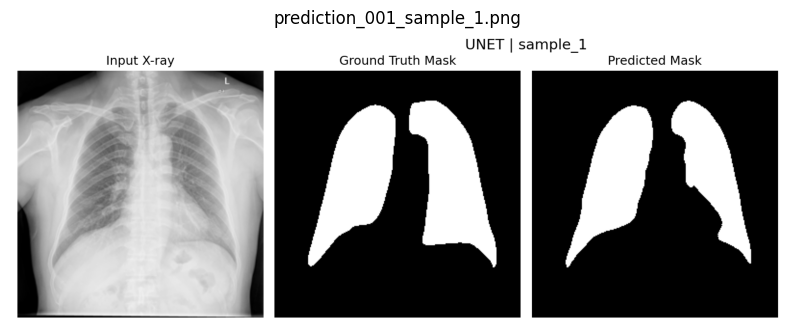

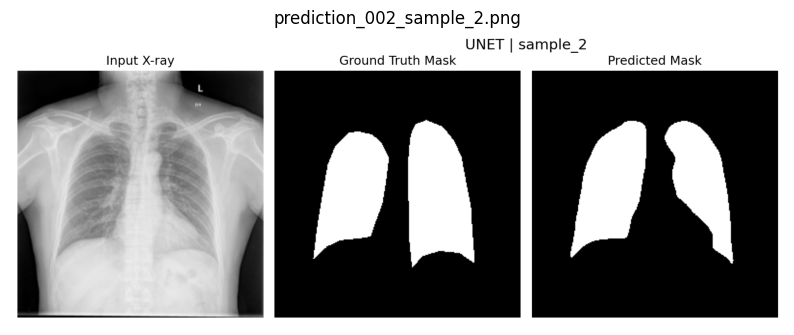

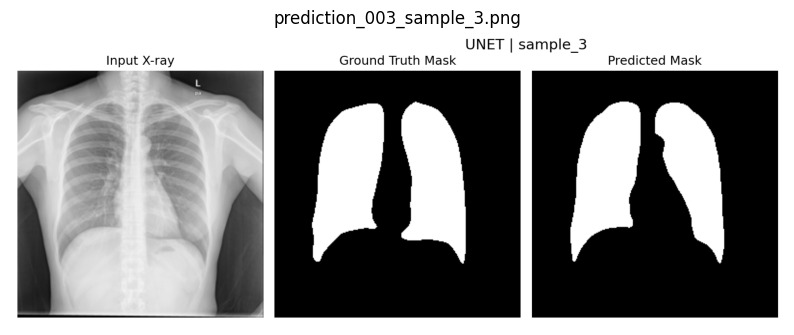

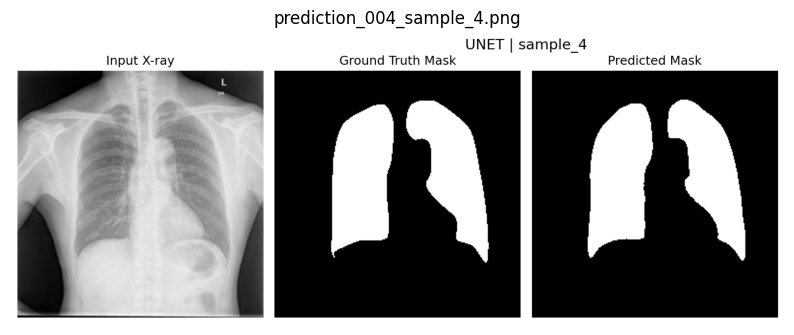

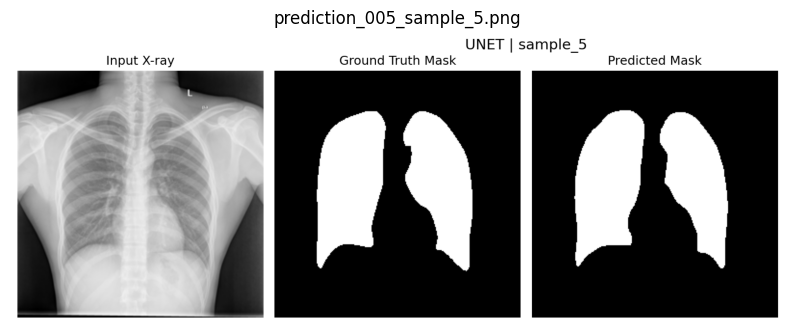

U-Net (SHCXR → JSRT) = Cross-dataset


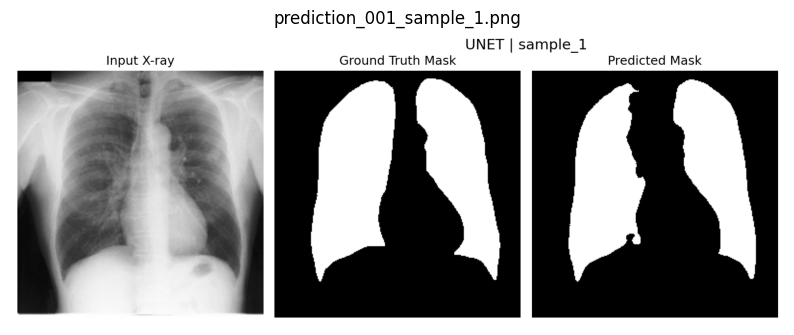

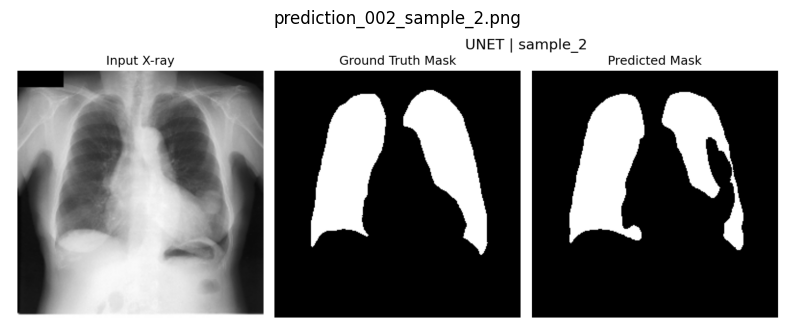

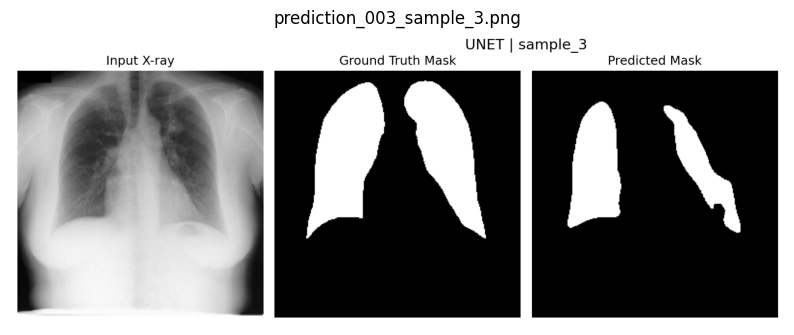

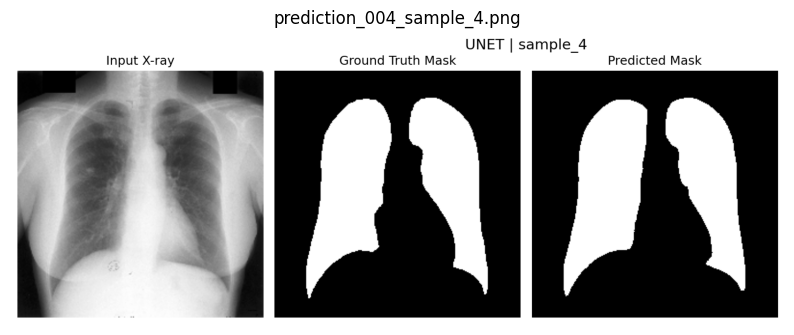

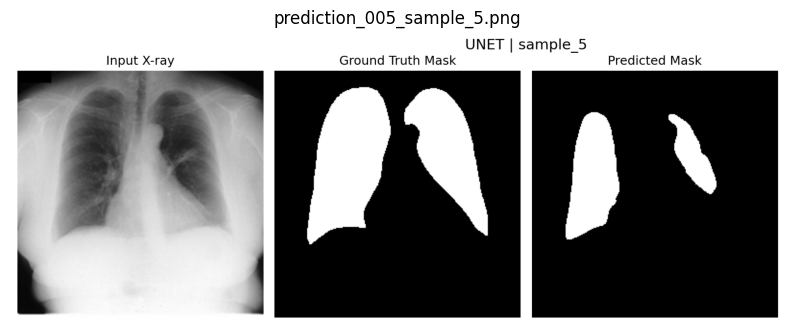

ResUNet (JSRT → JSRT) = Within-dataset


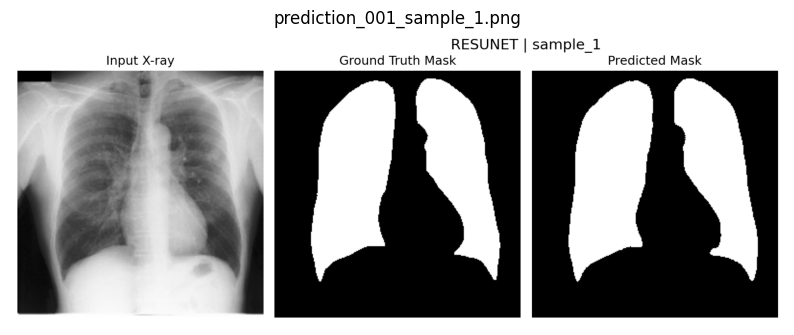

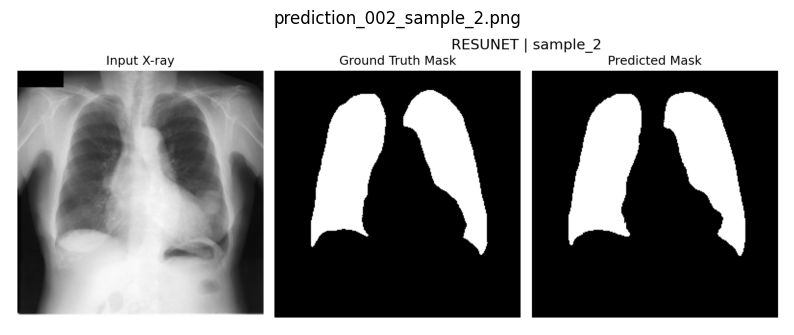

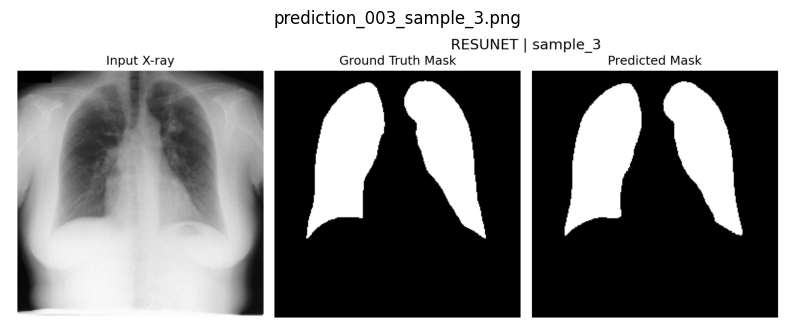

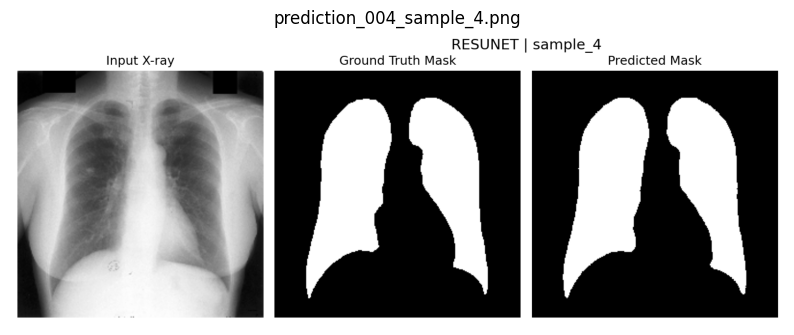

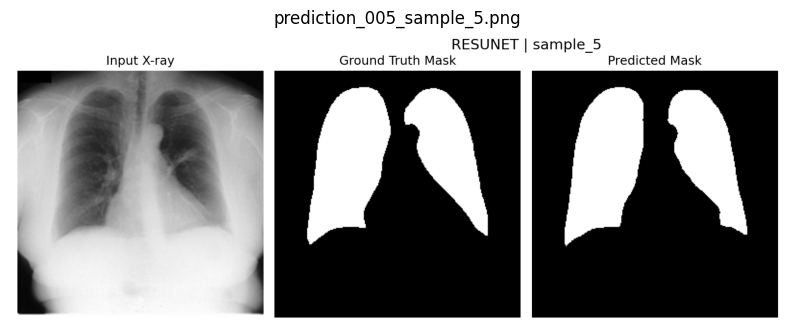

ResUNet (JSRT → SHCXR) = Cross-dataset


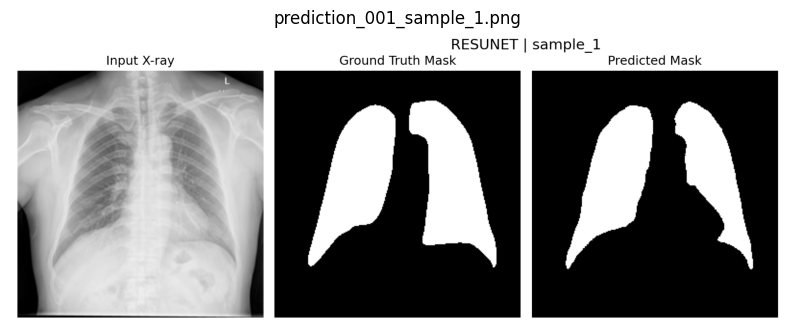

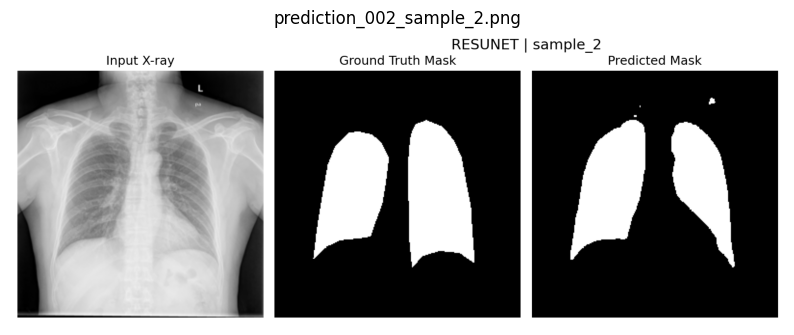

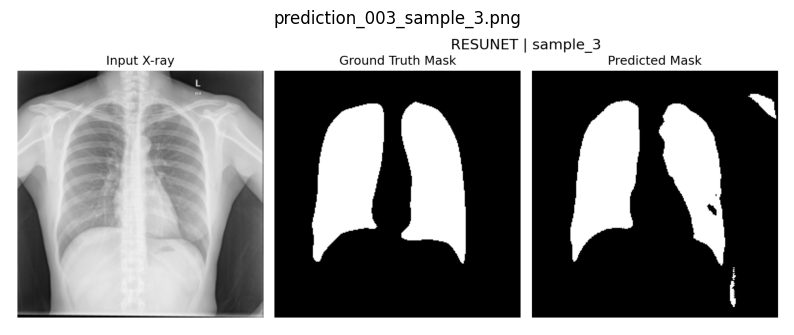

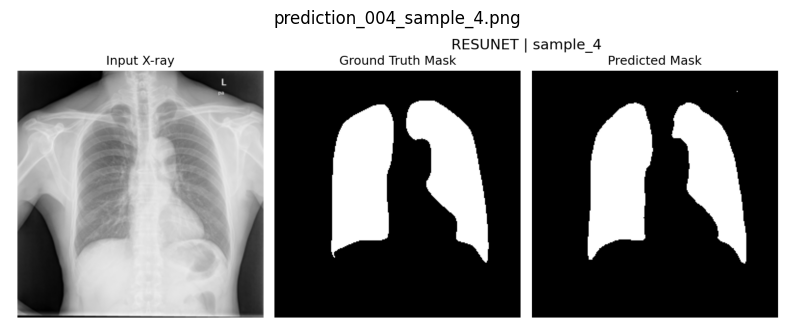

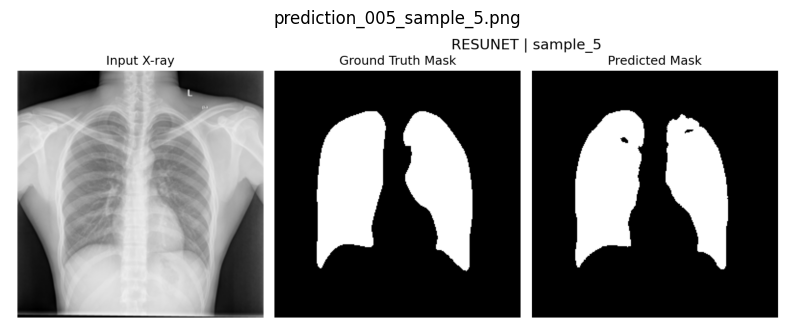

In [13]:
from pathlib import Path
from PIL import Image
import matplotlib.pyplot as plt

def disp_pred(dir, title, max_img=5):
    folder = Path(dir)
    image_paths = sorted(folder.glob("*.png"))[:max_img]

    if len(image_paths) == 0:
        print(f"No prediction images found in {dir}")
        return

    print(title)

    for img_path in image_paths:
        img = Image.open(img_path)

        plt.figure(figsize=(10, 4))
        plt.imshow(img)
        plt.axis("off")
        plt.title(img_path.name)
        plt.show()


disp_pred(
    "pred_vis/unet_shcxr",
    "U-Net (SHCXR → SHCXR) = Within-dataset"
)

print("=" * 60)

disp_pred(
    "pred_vis/unet_shcxr_to_jsrt",
    "U-Net (SHCXR → JSRT) = Cross-dataset"
)

print("=" * 60)

disp_pred(
    "pred_vis/resunet_jsrt",
    "ResUNet (JSRT → JSRT) = Within-dataset"
)

print("=" * 60)

disp_pred(
    "pred_vis/resunet_jsrt_to_shcxr",
    "ResUNet (JSRT → SHCXR) = Cross-dataset"
)